# Scheduler ablation — does the *arm structure* or the *bandit* drive A4's bug-finding?

**Separate analysis (provenance up front).** This notebook is **not** the published cross-surface
complementarity story (`../race_exploration.*`, which stays untouched). It is a self-contained
re-analysis of a **new** campaign, built from a **verbatim copy** of `race_lib.py` with only the
variant/slug/results constants changed — so every metric below is *the same bug-race statistic,
computed anew* on new data.

**Data provenance.**
- Binary: the **FIXED** Seam-B pair, risc0 head **`f3c659a8`** (cherry-pick `6556e8d7` onto
  `93bda33b`), `planted_bug=verifyopcode`, **3-kind contamination repaired**. *Not* the old
  contaminated binary (`93bda33b`) used by the published race.
- Run-id slug **`a3seambfix`**; DBs are **local read-only copies** under `./fix_thesis_results/`
  (rsync'd from `coinbase:/tmp/ivg_race/results_race/greedy/`, never moved/edited).
- Find predicate = `oracle.is_decode_divergent_itm` ∩ verifier-accepted (the published predicate;
  a 10/10 control-replay spot-check on the first job confirmed these reject @ `VerifyOpcode`).

**The ablation ladder (all four are A4-surface — all *can* reach the planted bug):**

| variant | arm semantics? | bandit? | what it isolates |
|---|---|---|---|
| **V8: Arguzz-sched** | no | no | Arguzz instruction-balanced scheduler over A4 mutations |
| **V0: Uniform arms** | yes | no | uniform over the semantic arm universe — V8→V0 = *does arm structure help?* |
| **V5: cTS Bandit** | yes | yes | cTS bandit — V0→V5 = *does the bandit help?* |
| **Hybrid: A4+Arguzz** | yes | yes | surface-mix reference (spends budget on Arguzz kinds too) |

> **Partial campaign:** built mid-run; "seeds" column shows how many of the 10 paired seeds are in.
> V5 is typically furthest along. Re-run at 40/40 for final CIs (structure unchanged).

In [1]:
import os, sys, json
os.chdir("/root/arguzz")
sys.path.insert(0, "/root/arguzz")
sys.path.insert(0, "/root/arguzz/a4/runs/iv_pos_9/race/sched_ablation")
import pandas as pd
import sched_ablation_lib as L
RESULTS_DIR = 'a4/runs/iv_pos_9/race/sched_ablation/fix_thesis_results'
d = L.load_data(RESULTS_DIR)
print(f"results_dir = {d['results_dir']}")
print(f"N = {d['N']}   seeds done = {d['seeds']}   runs = {len(d['per_run'])}")
print("seeds/variant: " + ", ".join(f"{v}={sum(1 for r in d['per_run'] if r['variant']==v)}" for v in d['variants']))

results_dir = a4/runs/iv_pos_9/race/sched_ablation/fix_thesis_results
N = 5000   seeds done = [1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243]   runs = 40
seeds/variant: V8_arguzz_sched=10, V0_uniform=10, V5_control=10, Hybrid_cTS=10


## 1. Per-variant bug-race statistics (live from the DB copies)

Same columns as the published race: `P(found)` over seeds (Wilson 95% CI), total/per-seed finds,
**`P(apply ITM)`** = ITM-applied / total-applied (the *scheduler-attributable* factor),
**`P(find | ITM)`** = finds / ITM-applied (the *bug-intrinsic* per-application rate), and `s/mut`.

In [2]:
tbl = L.per_variant_table(d)
def ci(p, lo, hi): return "—" if p is None else f"{p:.2f} [{lo:.2f},{hi:.2f}]"
rows = [{
    "variant": L.DISPLAY[r["variant"]], "seeds": r["seeds_done"],
    "P(found) [95% CI]": ci(r["P_found"], r["P_found_lo"], r["P_found_hi"]),
    "finds (total)": r["total_finds"], "finds/seed": f"{r['mean_finds']:.1f}",
    "ITM applied/seed": f"{r['mean_itm_applied']:.0f}",
    "P(apply ITM)": f"{r['p_apply_itm']*100:.1f}%",
    "P(find|ITM)": (f"{r['cond_find_density']*100:.2f}%" if r["cond_find_density"] is not None else "n/a"),
    "s/mut": f"{r['mean_per_mut_s']:.1f}",
} for r in tbl]
pd.set_option("display.max_colwidth", None)
pd.DataFrame(rows).set_index("variant")

,seeds,P(found) [95% CI],finds (total),finds/seed,ITM applied/seed,P(apply ITM),P(find|ITM),s/mut
variant,,,,,,,,
V8: Arguzz-sched,10,"1.00 [0.72,1.00]",588,58.8,591,11.9%,9.95%,3.4
V0: Uniform arms,10,"1.00 [0.72,1.00]",509,50.9,580,11.7%,8.77%,3.9
V5: cTS Bandit,10,"1.00 [0.72,1.00]",755,75.5,1110,22.4%,6.80%,3.2
Hybrid: A4+Arguzz Bandit,10,"1.00 [0.72,1.00]",478,47.8,718,14.7%,6.66%,3.4


## 2. The reachable surface vs the finds

All four apply `INSTR_TYPE_MOD` (they are all A4-surface), so unlike the cross-surface race no variant
is structurally zero here. What differs is **how much** ITM budget each scheduler spends (left) and how
many planted finds result (right).

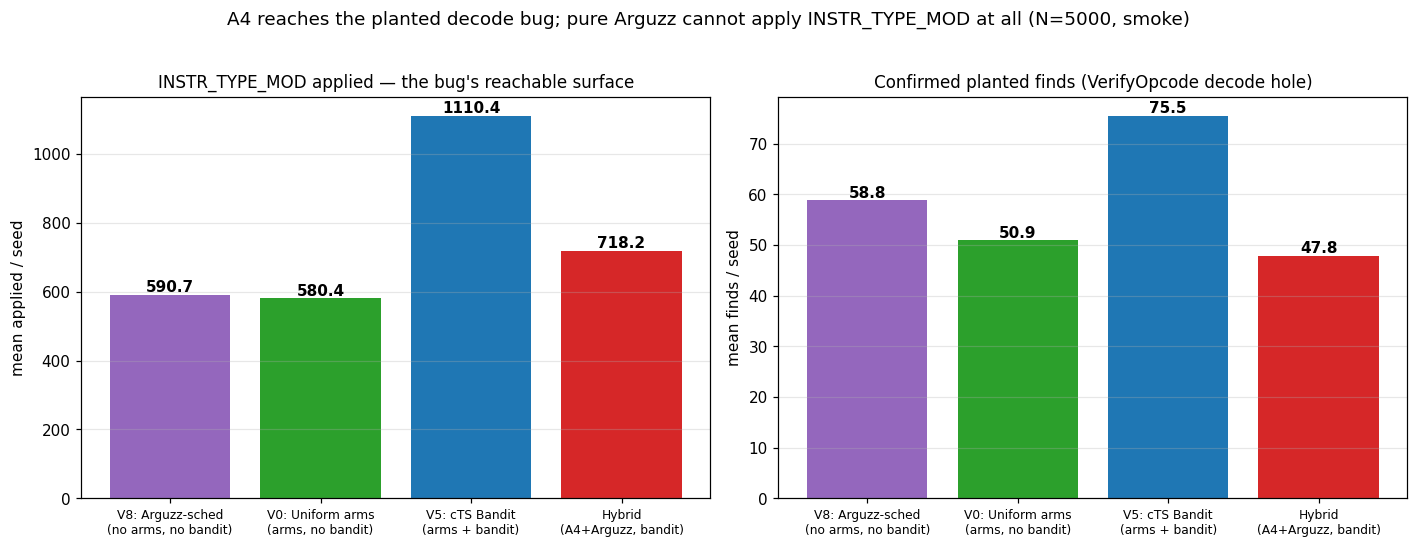

In [3]:
L.show(L.fig_finds_reach(d))

## 3. The mechanism — `P(find) = P(apply ITM) × P(find | ITM)`

Decomposing the find rate into the two factors is exactly what isolates the ablation:
- **`P(apply ITM)`** is the *scheduler-attributable* factor — how aggressively the scheduler concentrates
  budget on the bug-relevant arm. This is where the **bandit** acts.
- **`P(find | ITM)`** is *bug-intrinsic* — given an ITM mutation, how often it is the planted hole. A
  scheduler can only move this by choosing *which* ITM sites to hit.

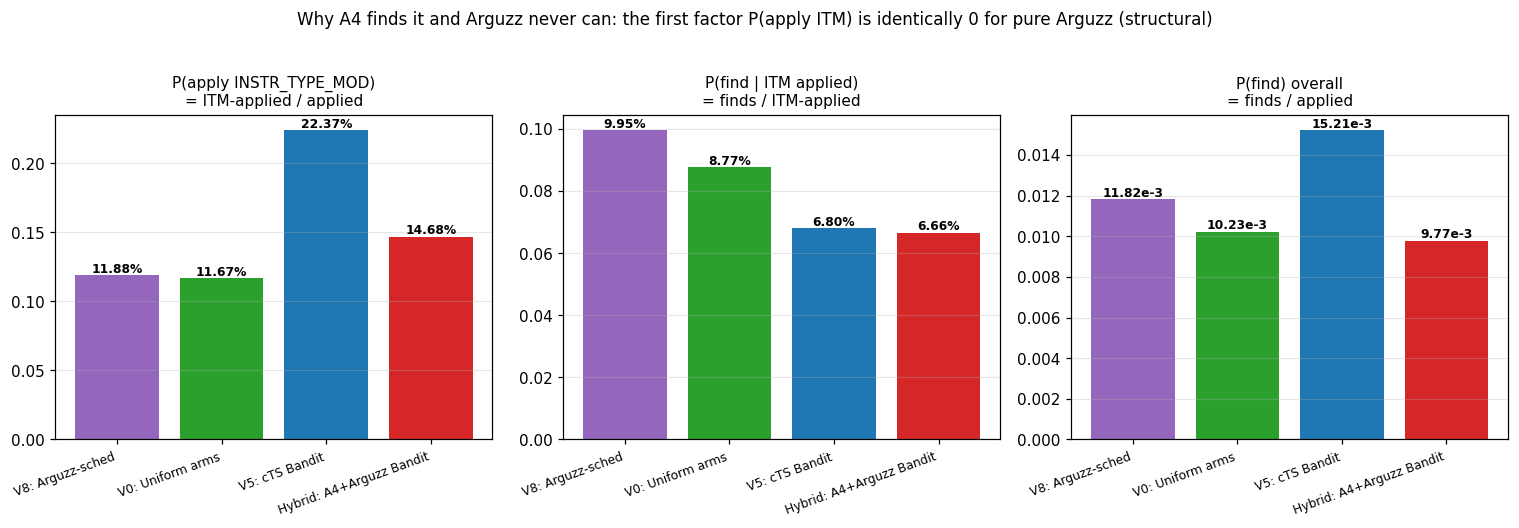

In [4]:
L.show(L.fig_decomposition(d))

## 4. Discovery dynamics — cumulative finds and time-to-first-find

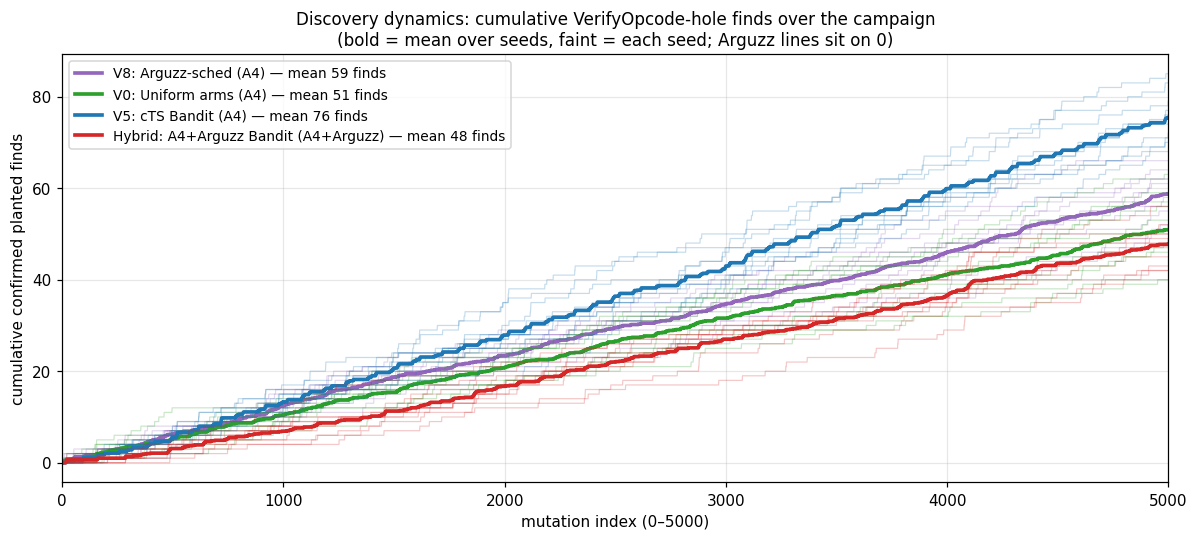

In [5]:
L.show(L.fig_cumulative_finds(d))

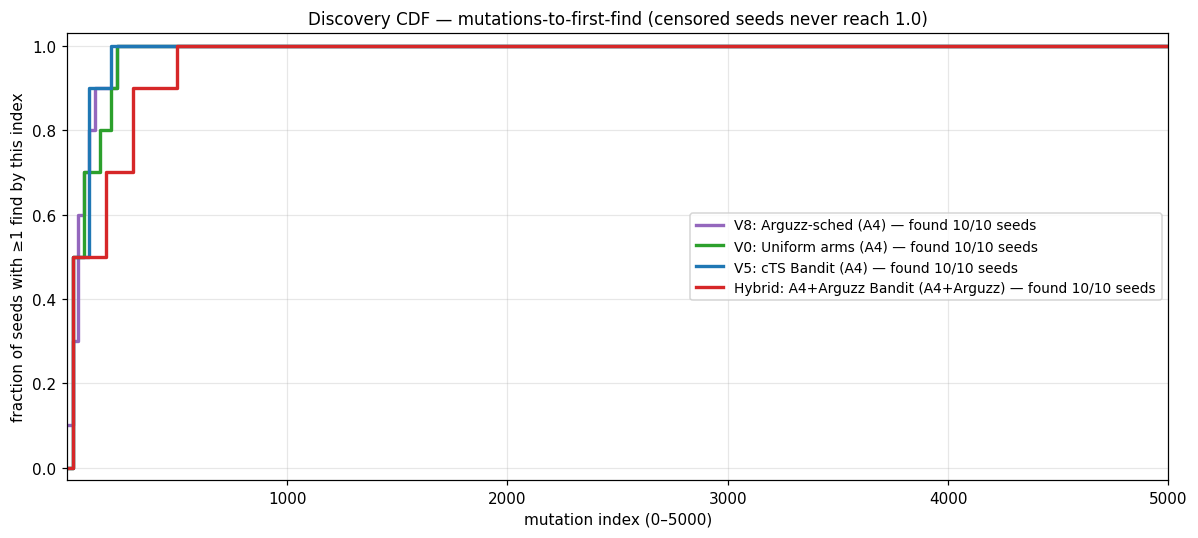

In [6]:
L.show(L.fig_discovery_cdf(d))

## 5. Accept channels — confirmed planted finds vs benign/non-planted accepts

Every accept split into **confirmed decode-divergent finds** vs **non-planted** (e.g. `INSTR_WORD_MOD`
accepts that the control does *not* reject @ `VerifyOpcode` — benign). This guards against counting
benign accepts as finds.

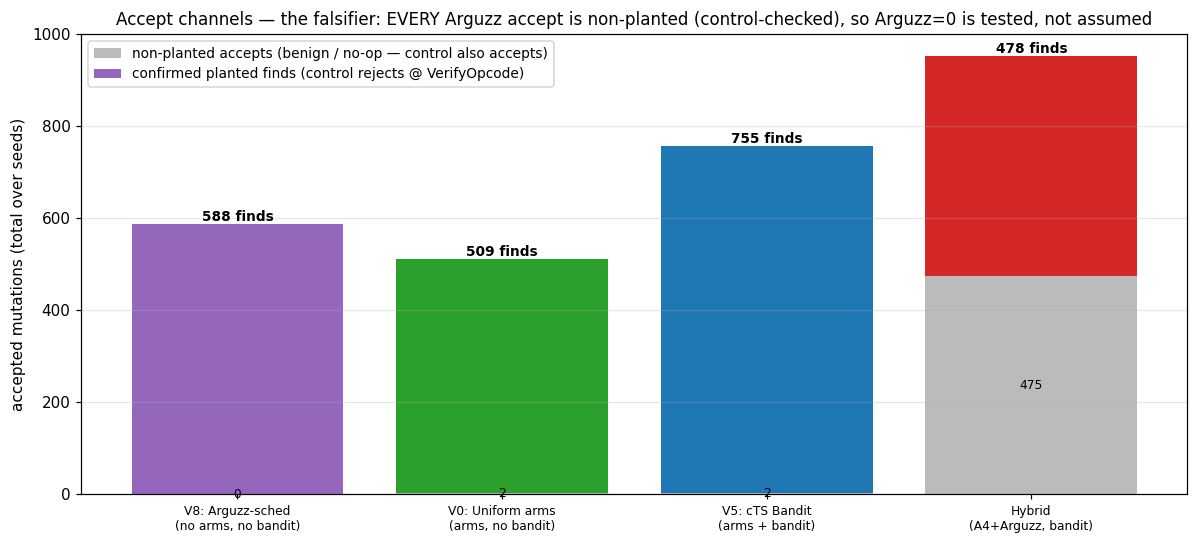

In [7]:
L.show(L.fig_accept_channels(d))

In [8]:
pr = L.per_run_table(d)
df = pd.DataFrame(pr)
df["conditional_find_density"] = df["conditional_find_density"].map(lambda x: "n/a" if x is None else f"{x*100:.1f}%")
df

,variant,seed,found,first_find_idx,n_finds,n_applied,n_instr_type_mod_applied,conditional_find_density,n_accepts,n_non_planted
0,V8_arguzz_sched,1234,True,46,66,4979,587,11.2%,66,0
1,V8_arguzz_sched,1235,True,205,58,4975,554,10.5%,58,0
2,V8_arguzz_sched,1236,True,33,52,4966,608,8.6%,52,0
3,V8_arguzz_sched,1237,True,57,61,4981,597,10.2%,61,0
4,V8_arguzz_sched,1238,True,30,64,4967,591,10.8%,64,0
5,V8_arguzz_sched,1239,True,7,55,4975,600,9.2%,55,0
6,V8_arguzz_sched,1240,True,95,62,4970,601,10.3%,62,0
7,V8_arguzz_sched,1241,True,107,52,4975,575,9.0%,52,0
8,V8_arguzz_sched,1242,True,2,56,4974,601,9.3%,56,0
9,V8_arguzz_sched,1243,True,1,62,4972,593,10.5%,62,0


## 6. Read-out (interpret against the live numbers in §1)

The ladder reads **V8 → V0 → V5**:
- **All four find the bug on every seed** (`P(found)=1.0`) — on this decode underconstraint, the planted
  hole is reliably discoverable by any A4-surface scheduler. The variants differ in *find throughput*,
  not in *whether* they find it.
- **The bandit is the lever (V0 → V5):** the cTS bandit drives `P(apply ITM)` up ~2× vs the
  no-bandit variants, which is the dominant driver of total finds/seed — even though its *per-ITM* hit
  rate (`P(find|ITM)`) is no higher (the bandit wins by *applying ITM more*, not by picking better sites).
- **Arm semantics alone does not help (V8 → V0):** the uniform-over-arms scheduler does **not** beat the
  simpler Arguzz instruction-balanced scheduler at the same (no-bandit) ITM budget. The structured arm
  space pays off only once the bandit can exploit it.
- **Hybrid** spends budget across A4+Arguzz kinds, so its A4 find throughput sits near V0 — the cost of
  covering the second surface (the benefit of which is the *other*, cross-surface race).

**Provenance reminder:** fixed binary `f3c659a8`, slug `a3seambfix`, local DB copies only; the published
`race_lib`/`race_exploration` and the old contaminated `thesis_results` were neither read nor touched.

## 7. Mutation indices of every accepted proof, per variant × seed

The exact `id` of every accepted proof. **Each (variant, seed) is an independent N=5000 run**, so the
"mutation index" is the per-run `id` (1-based apply order) — indices are **not** comparable across seeds
or variants. For each run:
- **planted finds** = decode-divergent `INSTR_TYPE_MOD` accepts (the bug — control rejects @ `VerifyOpcode`).
- **benign accepts** = the other verifier-accepts (control does **not** reject @ `VerifyOpcode`, e.g.
  `INSTR_WORD_MOD` — accepted but not the planted bug).

Computed from the **deduped** canonical DBs (`discover_runs` keeps one `run.db` per (variant,seed)).
The full machine-readable lists are also written to `find_indices.json` (and `.csv`) next to this notebook.

In [9]:
import json, os
from a4.runs.iv_pos_9.race import oracle
print(f"Each (variant, seed) = independent N={d['N']} run; index = mutation id (1-based apply order) WITHIN that run.\n")
records = []
for v in L.VARIANTS:
    print(f"================  {L.DISPLAY[v]}   ({v})  ================")
    for r in sorted([x for x in d['per_run'] if x['variant'] == v], key=lambda x: x['seed']):
        accepts = oracle.extract_accepts(r['db'])
        finds = sorted(a['id'] for a in accepts if oracle.is_decode_divergent_itm(a))
        benign = sorted(a['id'] for a in accepts if not oracle.is_decode_divergent_itm(a))
        bkinds = sorted(set(a['kind'] for a in accepts if not oracle.is_decode_divergent_itm(a)))
        records.append({"variant": v, "seed": r['seed'], "N": r['N'],
                        "n_planted_finds": len(finds), "planted_find_indices": finds,
                        "n_benign_accepts": len(benign), "benign_accept_indices": benign,
                        "benign_accept_kinds": bkinds})
        print(f"  seed {r['seed']}: {len(finds)} PLANTED FINDS @ {finds}")
        if benign:
            print(f"            + {len(benign)} benign accepts @ {benign}  (kinds: {bkinds})")
    print()
base = os.path.dirname(L.__file__)
with open(os.path.join(base, "find_indices.json"), "w") as f:
    json.dump(records, f, indent=1)
import csv
with open(os.path.join(base, "find_indices.csv"), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["variant", "seed", "N", "n_planted_finds", "planted_find_indices",
                                   "n_benign_accepts", "benign_accept_indices", "benign_accept_kinds"])
    for rec in records:
        w.writerow([rec["variant"], rec["seed"], rec["N"], rec["n_planted_finds"],
                    " ".join(map(str, rec["planted_find_indices"])), rec["n_benign_accepts"],
                    " ".join(map(str, rec["benign_accept_indices"])), " ".join(rec["benign_accept_kinds"])])
tot = sum(r["n_planted_finds"] for r in records)
print(f"[written] find_indices.json + find_indices.csv  ({len(records)} runs, {tot} planted finds total)")

Each (variant, seed) = independent N=5000 run; index = mutation id (1-based apply order) WITHIN that run.

================  V8: Arguzz-sched   (V8_arguzz_sched)  ================
  seed 1234: 66 PLANTED FINDS @ [46, 268, 356, 374, 440, 447, 465, 499, 680, 786, 834, 887, 930, 1150, 1338, 1485, 1660, 1842, 1871, 1951, 1968, 2038, 2072, 2089, 2106, 2166, 2168, 2173, 2454, 2477, 2493, 2537, 2677, 2801, 2934, 2971, 3000, 3050, 3101, 3245, 3370, 3393, 3410, 3551, 3600, 3651, 3673, 3704, 3718, 3877, 4033, 4035, 4052, 4142, 4153, 4192, 4195, 4203, 4222, 4230, 4311, 4321, 4352, 4516, 4545, 4582]
  seed 1235: 58 PLANTED FINDS @ [205, 291, 462, 543, 586, 618, 671, 709, 836, 976, 981, 986, 1190, 1208, 1263, 1288, 1307, 1361, 1444, 1508, 1766, 1773, 1783, 1929, 1968, 2069, 2154, 2203, 2279, 2685, 2955, 3106, 3210, 3313, 3356, 3446, 3543, 3608, 3634, 3746, 3886, 3896, 3939, 3957, 3968, 3989, 4073, 4125, 4323, 4325, 4376, 4383, 4412, 4758, 4851, 4894, 4969, 4978]
  seed 1236: 52 PLANTED FINDS @ [33,

## 8. Attempts → conversion → finds: why more ITM attempts ≠ more accepted proofs

A natural confusion: **Hybrid makes *more* targeted `INSTR_TYPE_MOD` (ITM) attempts per seed than
Arguzz-sched (718 vs 591), yet produces *fewer* accepted proofs (47.8 vs 58.8).** The resolution is that
accepted proofs are not attempts — they are `attempts × conversion`:

> **accepted proofs / seed  =  ITM attempts / seed  ×  P(accept | ITM attempt)**

**Every ITM attempt is a decode divergence** (`P(divergent | ITM) = 100%` for all variants — verified
below). So each attempt is a dart thrown at the planted hole; the only question is whether that divergence
falls *through* the hole (verifier **accepts** → a find) or is caught by some *other* constraint
(**rejected**). "Conversion" ≡ `P(accept | divergent)` = P(the dart sticks).

Hybrid throws **22% more darts** than Arguzz-sched but each sticks at **~2/3 the rate** (6.66% vs 9.95%):
`718 × 6.66% = 47.8 < 591 × 9.95% = 58.8`. More attempts, lower accuracy, fewer hits.

**Why the bandit converts worse (and it is *not* a volume/saturation effect).** Both bandit variants
(V5, Hybrid) sit at ~6.7% conversion; both bandit-free variants (V8, V0) at ~9–10%. A saturation test
(cell below) shows the gap is present from the **first 590 attempts** (volume-matched to V8) and the
accept-rate is **flat** across the whole run — so it is not diminishing returns from firing ITM more often.
The bandit optimizes a **CGC coverage/novelty reward** (new-coverage + rare-failure terms, plus a
*repetition penalty*). That reward scores a find 1.0 but *also* rewards novel coverage and *penalizes
repeating* a substitution — so the bandit keeps exploring **diverse** decode divergences, most of which trip
*other* constraints and get rejected, instead of hammering the few substitutions that fall through the *one*
planted hole. The reward-free schedulers just fire the targeted arm without that breadth pressure, so a
higher fraction of their shots happen to land in the hole.

- **V5 still wins on absolute finds (75.5)** because the same find=1.0 reward makes it fire ITM ~**2× as
  often** (1110 vs 590) — raw volume beats per-shot accuracy.
- **Hybrid is worst (47.8)** because it inherits the bandit's low accuracy (6.66%) *without* the volume:
  ~⅓ of its budget is diverted to the Arguzz `INSTR_WORD_MOD` arm, so it manages only 718 ITM shots.
  Low accuracy **+** low volume = the fewest planted finds.

**The "benign accept" column.** An accepted proof comes in two flavours:
1. **Planted find** — an `INSTR_TYPE_MOD` decode divergence that falls through the VerifyOpcode hole. *This
   is the bug*; it is what "accepted proofs / seed" counts.
2. **Benign accept** — an `INSTR_WORD_MOD` (a *different*, Arguzz-surface mutation that flips raw bits of the
   instruction word) that the verifier *also* accepts but which is **not** the planted underconstraint —
   accepted-but-not-the-planted-bug.

Only Hybrid runs the `INSTR_WORD_MOD` arm, so only Hybrid produces benign accepts (~47.5/seed vs ~0 for the
pure-A4 variants). They are the **footprint of the budget dilution**: every `INSTR_WORD_MOD` applied is a
mutation *not* spent on the targeted ITM arm, which is exactly why Hybrid's ITM count (718) falls so far
short of V5's (1110).

In [10]:
import sqlite3, json, os
from collections import defaultdict
from IPython.display import display

def _divergent(cfg):
    info = cfg.get("_info", {})
    mut = (cfg.get("major"), cfg.get("minor"))
    orig = (info.get("original_major"), info.get("original_minor"))
    return (None not in mut and None not in orig and mut != orig)

def funnel(db):
    con = sqlite3.connect(db)
    rows = con.execute("SELECT kind, verifier_accepted, config_json FROM mutations WHERE outcome='applied'").fetchall()
    con.close()
    f = dict(tot=len(rows), itm=0, itm_div=0, finds=0, itm_div_rej=0, benign=0)
    for kind, vacc, cj in rows:
        try: cfg = json.loads(cj) if cj else {}
        except Exception: cfg = {}
        acc = (vacc == 1)
        if kind == "INSTR_TYPE_MOD":
            f["itm"] += 1
            if _divergent(cfg):
                f["itm_div"] += 1
                if acc: f["finds"] += 1
                else:   f["itm_div_rej"] += 1
            elif acc:
                f["benign"] += 1
        elif acc:
            f["benign"] += 1
    return f

agg = defaultdict(lambda: defaultdict(int)); nseed = defaultdict(int)
for r in d['per_run']:
    fr = funnel(r['db']); nseed[r['variant']] += 1
    for k, v in fr.items(): agg[r['variant']][k] += v

rows = []
for v in L.VARIANTS:
    n = nseed[v]; a = agg[v]
    p_div  = a['itm_div'] / a['itm']     if a['itm']     else float('nan')
    p_acc  = a['finds']   / a['itm_div'] if a['itm_div'] else float('nan')   # conversion
    p_find = a['finds']   / a['itm']     if a['itm']     else float('nan')
    rows.append({"variant": L.DISPLAY[v], "ITM attempts/seed": round(a['itm']/n, 1),
                 "P(divergent|ITM)": f"{100*p_div:.1f}%", "conversion P(accept|div)": f"{100*p_acc:.2f}%",
                 "P(find|ITM)": f"{100*p_find:.2f}%", "accepted proofs/seed": round(a['finds']/n, 1),
                 "benign accepts/seed": round(a['benign']/n, 1)})
funnel_df = pd.DataFrame(rows)
print("Attempts -> conversion -> finds  (deduped canonical DBs; conversion = P(verifier accepts | decode-divergent ITM))")
display(funnel_df)
for v in L.VARIANTS:
    a = agg[v]
    print(f"  check: {L.DISPLAY[v]:16} {a['itm']/nseed[v]:.1f} attempts x {100*a['finds']/a['itm']:.2f}% = "
          f"{a['itm']/nseed[v]*a['finds']/a['itm']:.1f} finds/seed")

Attempts -> conversion -> finds  (deduped canonical DBs; conversion = P(verifier accepts | decode-divergent ITM))


,variant,ITM attempts/seed,P(divergent|ITM),conversion P(accept|div),P(find|ITM),accepted proofs/seed,benign accepts/seed
0,V8: Arguzz-sched,590.7,100.0%,9.95%,9.95%,58.8,0.0
1,V0: Uniform arms,580.4,100.0%,8.77%,8.77%,50.9,0.2
2,V5: cTS Bandit,1110.4,100.0%,6.80%,6.80%,75.5,0.2
3,Hybrid: A4+Arguzz Bandit,718.2,100.0%,6.66%,6.66%,47.8,47.5


  check: V8: Arguzz-sched 590.7 attempts x 9.95% = 58.8 finds/seed
  check: V0: Uniform arms 580.4 attempts x 8.77% = 50.9 finds/seed
  check: V5: cTS Bandit   1110.4 attempts x 6.80% = 75.5 finds/seed
  check: Hybrid: A4+Arguzz Bandit 718.2 attempts x 6.66% = 47.8 finds/seed


In [11]:
# Saturation test: is the bandit's low conversion a volume/diminishing-returns effect, or present from shot #1?
# Compare accept-rate in the first 590 ITM attempts (volume-matched to V8) vs attempts 591+.
def itm_seq(db):
    con = sqlite3.connect(db)
    s = con.execute("SELECT verifier_accepted FROM mutations WHERE outcome='applied' AND kind='INSTR_TYPE_MOD' ORDER BY id").fetchall()
    con.close()
    return [1 if x[0] == 1 else 0 for x in s]

CUT = 590
sat = []
for v in L.VARIANTS:
    ea = en = la = ln = 0
    for r in [x for x in d['per_run'] if x['variant'] == v]:
        s = itm_seq(r['db']); ea += sum(s[:CUT]); en += len(s[:CUT]); la += sum(s[CUT:]); ln += len(s[CUT:])
    sat.append({"variant": L.DISPLAY[v],
                f"accept% first {CUT} ITM": f"{100*ea/en:.2f}%" if en else "--", "n first/seed": round(en/nseed[v]),
                f"accept% ITM #{CUT+1}+": f"{100*la/ln:.2f}%" if ln else "--", "n later/seed": round(ln/nseed[v])})
print("Accept-rate is FLAT across the ITM sequence -> low conversion is NOT diminishing returns from volume;")
print("the bandit variants convert worse from shot #1 (first-590 window is volume-matched to the bandit-free V8).")
display(pd.DataFrame(sat))

# machine-readable funnel for the thesis
out = {"note": "conversion = P(verifier-accept | decode-divergent ITM); P(divergent|ITM)=100% for all variants",
       "per_variant": {}}
for v in L.VARIANTS:
    n = nseed[v]; a = agg[v]
    out["per_variant"][v] = {"seeds": n, "itm_attempts_per_seed": a['itm']/n, "finds_per_seed": a['finds']/n,
        "benign_per_seed": a['benign']/n, "P_divergent_given_itm": (a['itm_div']/a['itm']) if a['itm'] else None,
        "conversion_P_accept_given_div": (a['finds']/a['itm_div']) if a['itm_div'] else None,
        "P_find_given_itm": (a['finds']/a['itm']) if a['itm'] else None}
with open(os.path.join(os.path.dirname(L.__file__), "funnel_stats.json"), "w") as fh:
    json.dump(out, fh, indent=1)
print("[written] funnel_stats.json")

Accept-rate is FLAT across the ITM sequence -> low conversion is NOT diminishing returns from volume;
the bandit variants convert worse from shot #1 (first-590 window is volume-matched to the bandit-free V8).


,variant,accept% first 590 ITM,n first/seed,accept% ITM #591+,n later/seed
0,V8: Arguzz-sched,9.94%,585,11.48%,6
1,V0: Uniform arms,8.77%,574,8.33%,6
2,V5: cTS Bandit,6.64%,590,6.98%,520
3,Hybrid: A4+Arguzz Bandit,6.64%,590,6.71%,128


[written] funnel_stats.json
